# Uncertainty Estimation: Probabilistic ML for Perovskite Research

## 1. Why Uncertainty Matters in Science
A single-point prediction (e.g., "PCE will be 19.5%") can be misleading if the model is guessing in an unexplored chemical region. 

In this notebook, we implement **Quantile Regression** using XGBoost. Instead of predicting just the mean, we predict:
*   **5th Percentile (Lower Bound):** 95% of results will be above this.
*   **50th Percentile (Median):** The most likely result.
*   **95th Percentile (Upper Bound):** 95% of results will be below this.

The distance between the 5th and 95th percentiles is our **Prediction Interval**. A wide interval means high uncertainty.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("Libraries loaded.")

Libraries loaded.


## 2. Data Preparation
We will focus on **Band Gap** prediction for this demonstration, as it has a clean physical relationship with composition.

In [2]:
df = pd.read_parquet("../data/enriched_perovskites.parquet")
df.dropna(subset=['band_gap', 'tolerance_factor'], inplace=True)

y = df['band_gap']
X = df.drop(columns=[
    'composition_long_form', 'composition_short_form', 'band_gap',
    'A_1_coef', 'A_2_coef', 'A_3_coef', 'B_1_coef', 'B_2_coef',
    'C_1_coef', 'C_2_coef', 'C_3_coef', 'C_3', 'B_2',
    'r_A', 'r_B', 'r_C'
])

categorical_features = ['A_1', 'A_2', 'A_3', 'B_1', 'C_1', 'C_2', 'dimension', 'space_group']
numerical_features = [col for col in X.columns if col not in categorical_features]

for col in categorical_features:
    X[col] = X[col].fillna('None').astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print(f"Dataset split: {len(X_train)} training, {len(X_test)} testing samples.")

Dataset split: 648 training, 163 testing samples.


## 3. Training Quantile Models
We train three separate models using the `reg:quantileerror` objective. 
*Note: This requires XGBoost 2.0+.*

In [3]:
common_params = {
    'n_estimators': 500,
    'max_depth': 6,
    'learning_rate': 0.1,
    'tree_method': 'hist', # Faster training
    'random_state': 42
}

print("Training Median Model (q=0.5)...")
model_median = Pipeline([('pre', preprocessor), ('reg', XGBRegressor(objective='reg:absoluteerror', **common_params))])
model_median.fit(X_train, y_train)

print("Training Lower Bound Model (q=0.05)...")
model_low = Pipeline([('pre', preprocessor), ('reg', XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.05, **common_params))])
model_low.fit(X_train, y_train)

print("Training Upper Bound Model (q=0.95)...")
model_high = Pipeline([('pre', preprocessor), ('reg', XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.95, **common_params))])
model_high.fit(X_train, y_train)

print("Training complete.")

Training Median Model (q=0.5)...
Training Lower Bound Model (q=0.05)...
Training Upper Bound Model (q=0.95)...
Training complete.


## 4. Visualizing Prediction Intervals
We plot the predicted intervals against the ground truth. We expect ~90% of actual values to fall within the shaded region.

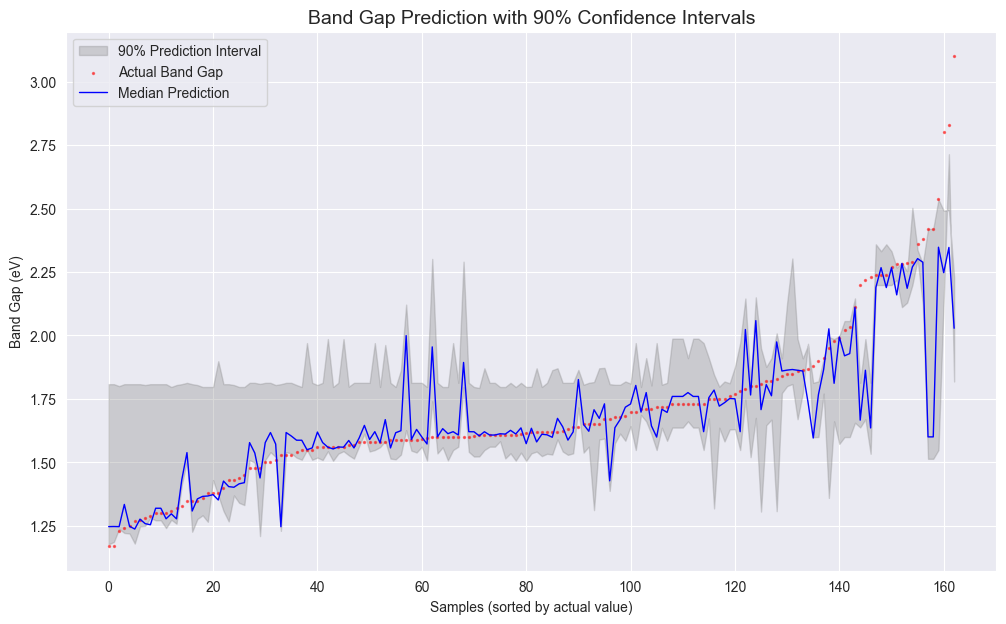

Empirical Coverage: 77.91% (Target: 90%)


In [4]:
preds_median = model_median.predict(X_test)
preds_low = model_low.predict(X_test)
preds_high = model_high.predict(X_test)

# Sort for better visualization
idx = np.argsort(y_test)
y_test_sorted = y_test.iloc[idx].values
preds_median_sorted = preds_median[idx]
preds_low_sorted = preds_low[idx]
preds_high_sorted = preds_high[idx]

plt.figure(figsize=(12, 7))
plt.fill_between(range(len(y_test)), preds_low_sorted, preds_high_sorted, color='gray', alpha=0.3, label='90% Prediction Interval')
plt.scatter(range(len(y_test)), y_test_sorted, s=2, color='red', label='Actual Band Gap', alpha=0.5)
plt.plot(range(len(y_test)), preds_median_sorted, color='blue', linewidth=1, label='Median Prediction')

plt.title("Band Gap Prediction with 90% Confidence Intervals", fontsize=14)
plt.xlabel("Samples (sorted by actual value)")
plt.ylabel("Band Gap (eV)")
plt.legend()
plt.show()

# Calculate Coverage
within_interval = (y_test >= preds_low) & (y_test <= preds_high)
coverage = np.mean(within_interval)
print(f"Empirical Coverage: {coverage*100:.2f}% (Target: 90%)")

## 5. Case Study: Identifying High-Uncertainty Regions
We can calculate the "Uncertainty Score" (Interval Width) and correlate it with features.

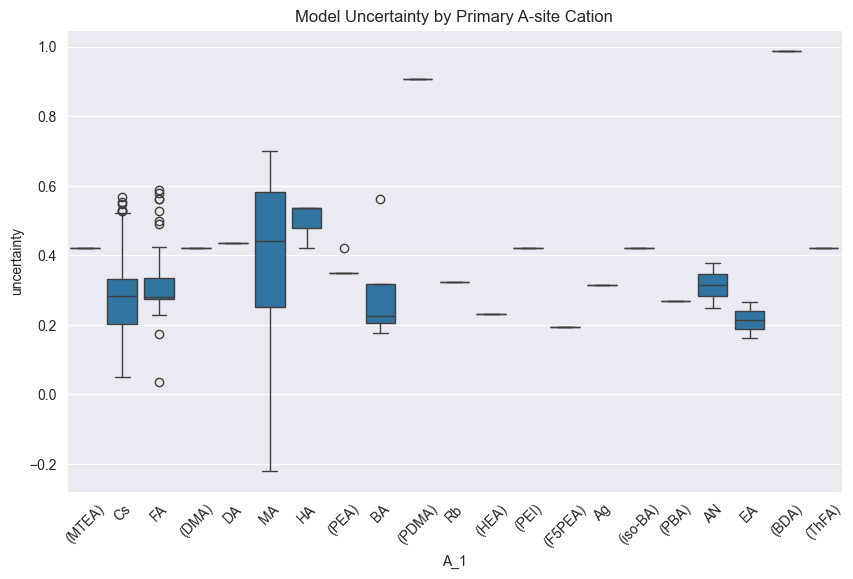

In [5]:
uncertainty = preds_high - preds_low
X_test_res = X_test.copy()
X_test_res['uncertainty'] = uncertainty

plt.figure(figsize=(10, 6))
sns.boxplot(x='A_1', y='uncertainty', data=X_test_res)
plt.title("Model Uncertainty by Primary A-site Cation")
plt.xticks(rotation=45)
plt.show()

## 6. Conclusion for Diploma

By implementing uncertainty estimation, we provide a **Safety Metric** for experimentalists:
1.  **Trustworthiness:** Compositions with narrow intervals can be moved to the lab immediately.
2.  **Experimental Guidance:** Regions with high uncertainty indicate where the model lacks data, suggesting where new experiments should be performed (**Active Learning**).
3.  **Scientific Rigor:** This mimics the error bars found in physical measurements, making the ML model's output more compatible with standard scientific communication.